In [1]:
import scanpy as sc
import celltypist
from celltypist import models
import time
import numpy as np
import pandas as pd

In [2]:
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80,dpi_save=100,color_map='Reds')
sc.logging.print_version_and_date()

import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
plt.show()
matplotlib.rcParams.update({'figure.figsize': (6,6)})

Running Scanpy 1.10.3, on 2025-11-25 08:35.


### Tyser and Xiang label transfer

In [67]:
Tyser_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model.pkl")
Xiang_model = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Xiang_model.pkl")
Tyser_model_v2 = models.Model.load(model="/mnt/yiming/nfs_share/hema_wave/Tyser_model_v2.pkl")

In [68]:
Tyser_model.cell_types

array(['Advanced Mesoderm', 'Amnion', 'Axial Mesoderm',
       'Blood Progenitors', 'DE(NP)', 'DE(P)', 'Emergent Mesoderm',
       'Epiblast', 'Erythro-Myeloid Progenitors', 'Erythroblasts',
       'Hemogenic Endothelium', 'Hypoblast', 'Myeloid Progenitors', 'NNE',
       'Nascent Mesoderm', 'PGC', 'Primitive Streak', 'YS Endoderm',
       'YS Mesoderm'], dtype=object)

In [69]:
Tyser_model_v2.cell_types

array(['Advanced Mesoderm', 'Axial Mesoderm', 'Emergent Mesoderm',
       'Endoderm', 'Epiblast', 'Erythroblasts', 'ExE Mesoderm',
       'Hemogenic Endothelial Progenitors', 'Nascent Mesoderm',
       'Non-Neural Ectoderm', 'Primitive Streak'], dtype=object)

In [46]:
sc.pp.normalize_total(adata, target_sum = 1e4) #Note this is only for cell annotation, recommended by authors but not best
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:00)


In [47]:
adata = adata.raw.to_adata()

In [52]:
adata.obs_names_make_unique()

In [53]:
predictions = celltypist.annotate(adata, model=Tyser_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 68498 cells and 18732 genes
🔗 Matching reference genes in the model
🧬 2878 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20


running Leiden clustering
    finished: found 276 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:35)


🗳️ Majority voting the predictions
✅ Majority voting done!


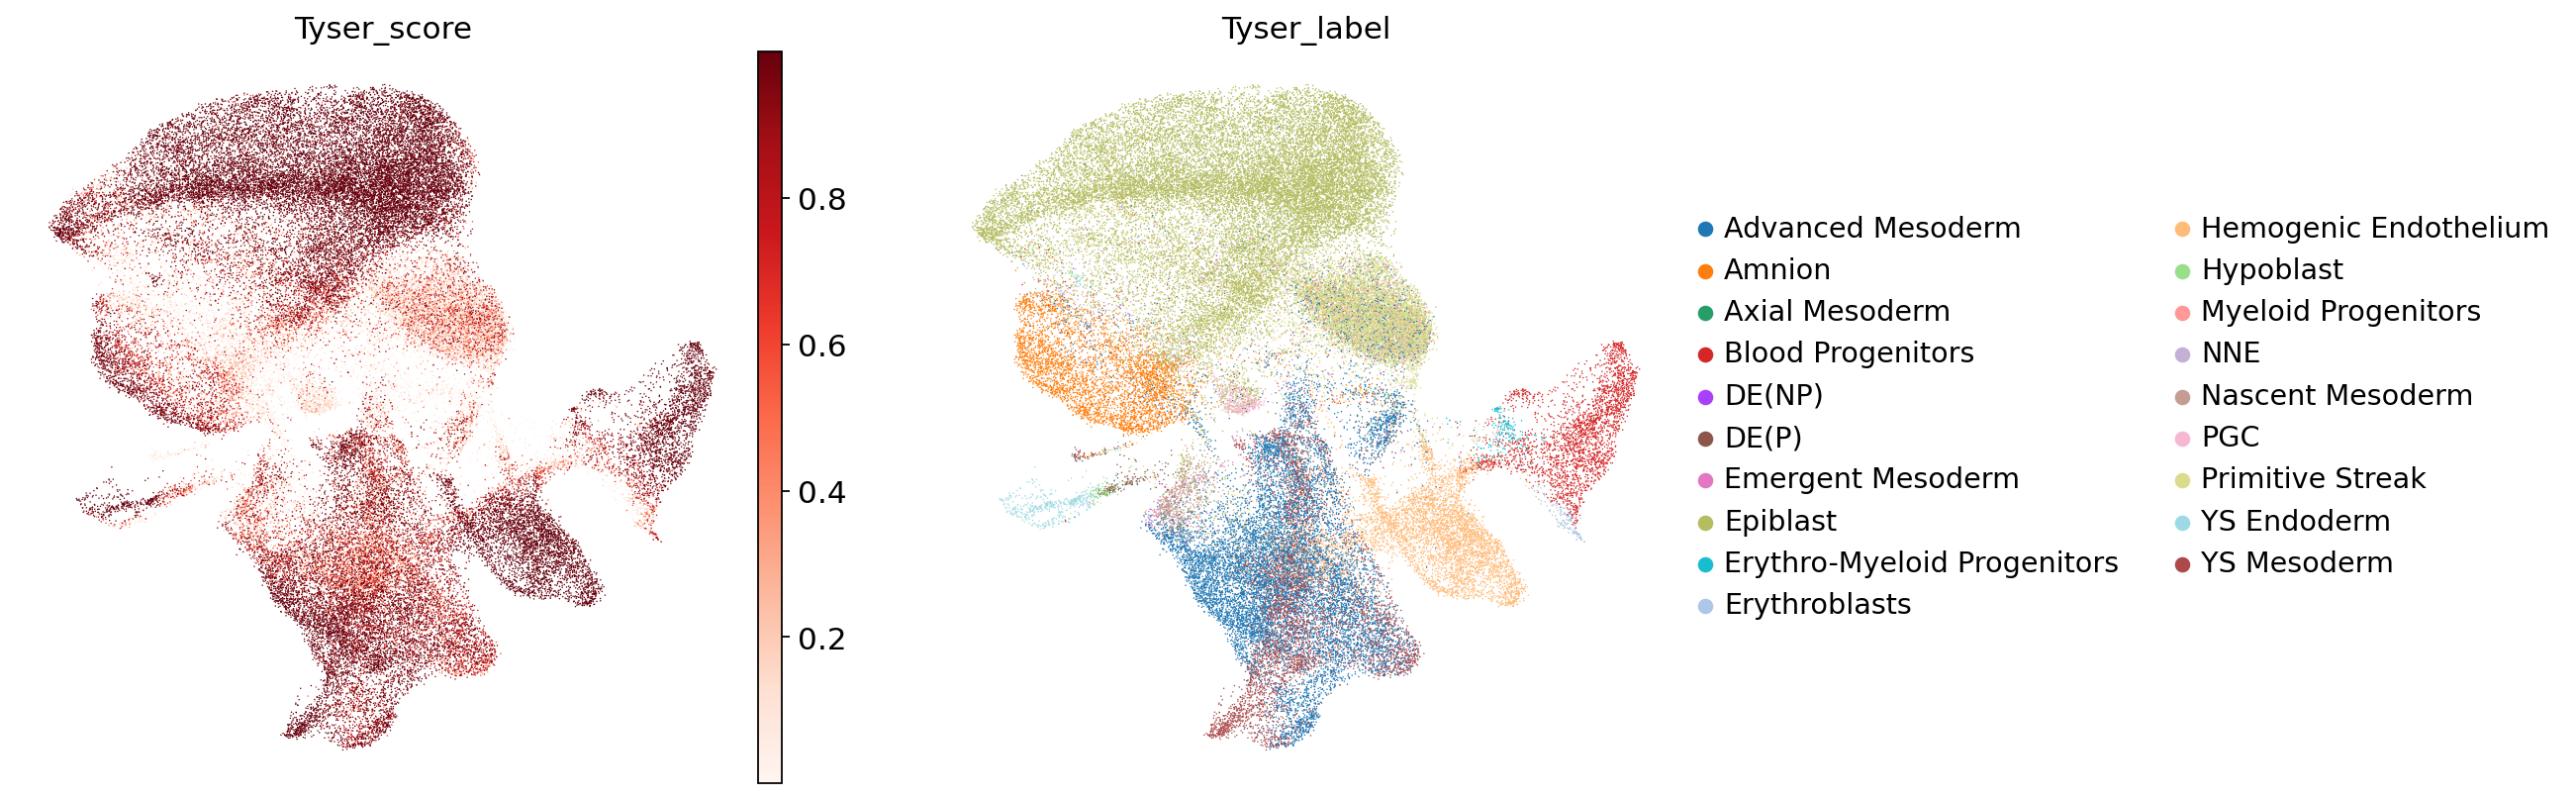

In [58]:
sc.pl.umap(adata, color=['Tyser_score', 'Tyser_label'], frameon=False)

In [72]:
predictions = celltypist.annotate(adata, model=Tyser_model_v2, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Tyser_label_v2"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Tyser_score_v2"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 68498 cells and 18732 genes
🔗 Matching reference genes in the model
🧬 2228 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20


running Leiden clustering
    finished: found 276 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:35)


🗳️ Majority voting the predictions
✅ Majority voting done!


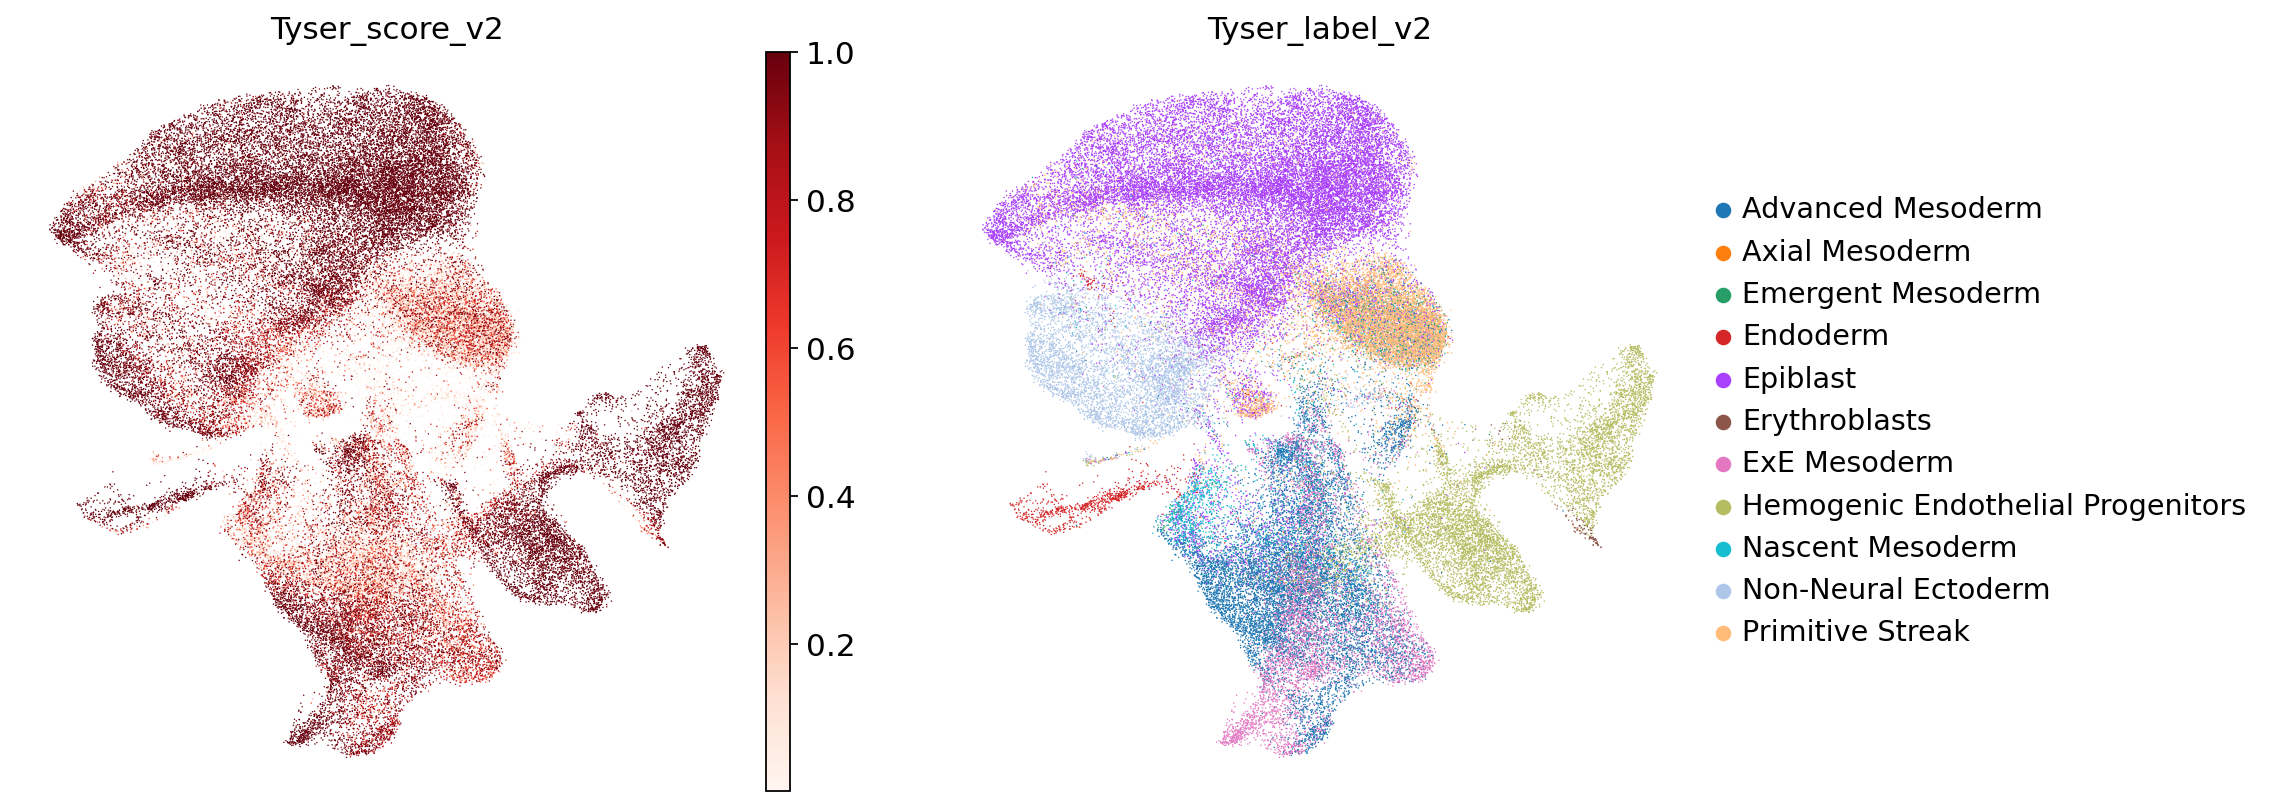

In [75]:
sc.pl.umap(adata, color=['Tyser_score_v2', 'Tyser_label_v2'], frameon=False)

In [55]:
predictions = celltypist.annotate(adata, model=Xiang_model, majority_voting=True)
predictions_adata = predictions.to_adata()
adata.obs["Xiang_label"] = predictions_adata.obs.loc[adata.obs.index, "predicted_labels"]
adata.obs["Xiang_score"] = predictions_adata.obs.loc[adata.obs.index, "conf_score"]

⚠️ Warning: invalid expression matrix, expect ALL genes and log1p normalized expression to 10000 counts per cell. The prediction result may not be accurate
🔬 Input data has 68498 cells and 18732 genes
🔗 Matching reference genes in the model
🧬 1443 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20


running Leiden clustering


IOStream.flush timed out


    finished: found 276 clusters and added
    'over_clustering', the cluster labels (adata.obs, categorical) (0:00:35)


🗳️ Majority voting the predictions
✅ Majority voting done!


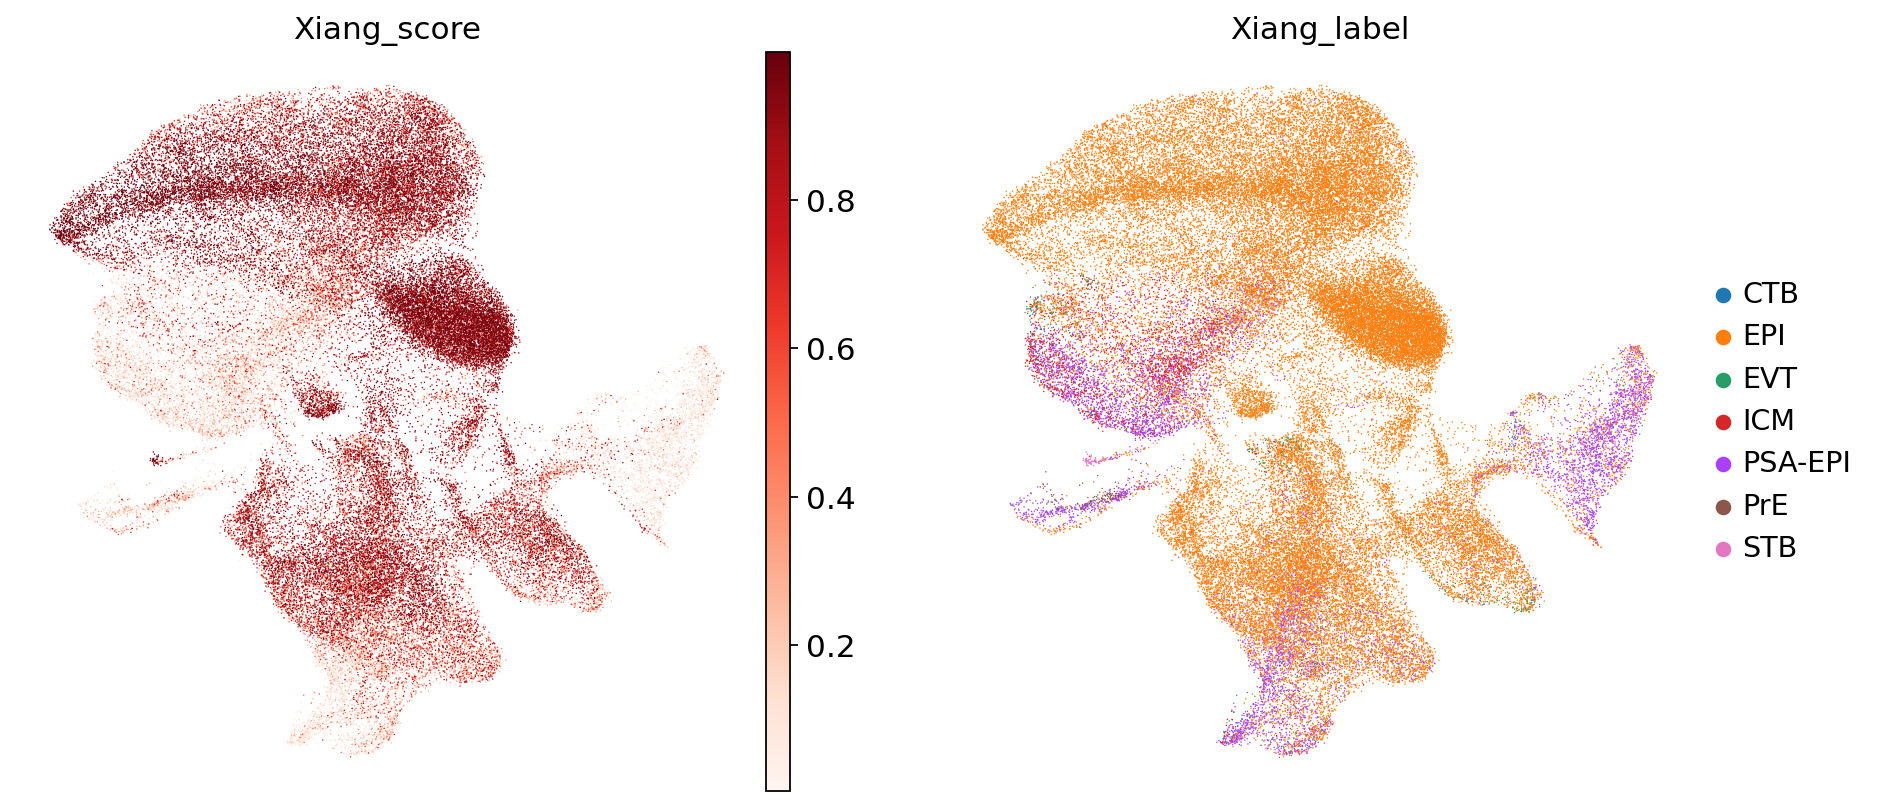

In [59]:
sc.pl.umap(adata, color=['Xiang_score', 'Xiang_label'], frameon=False)

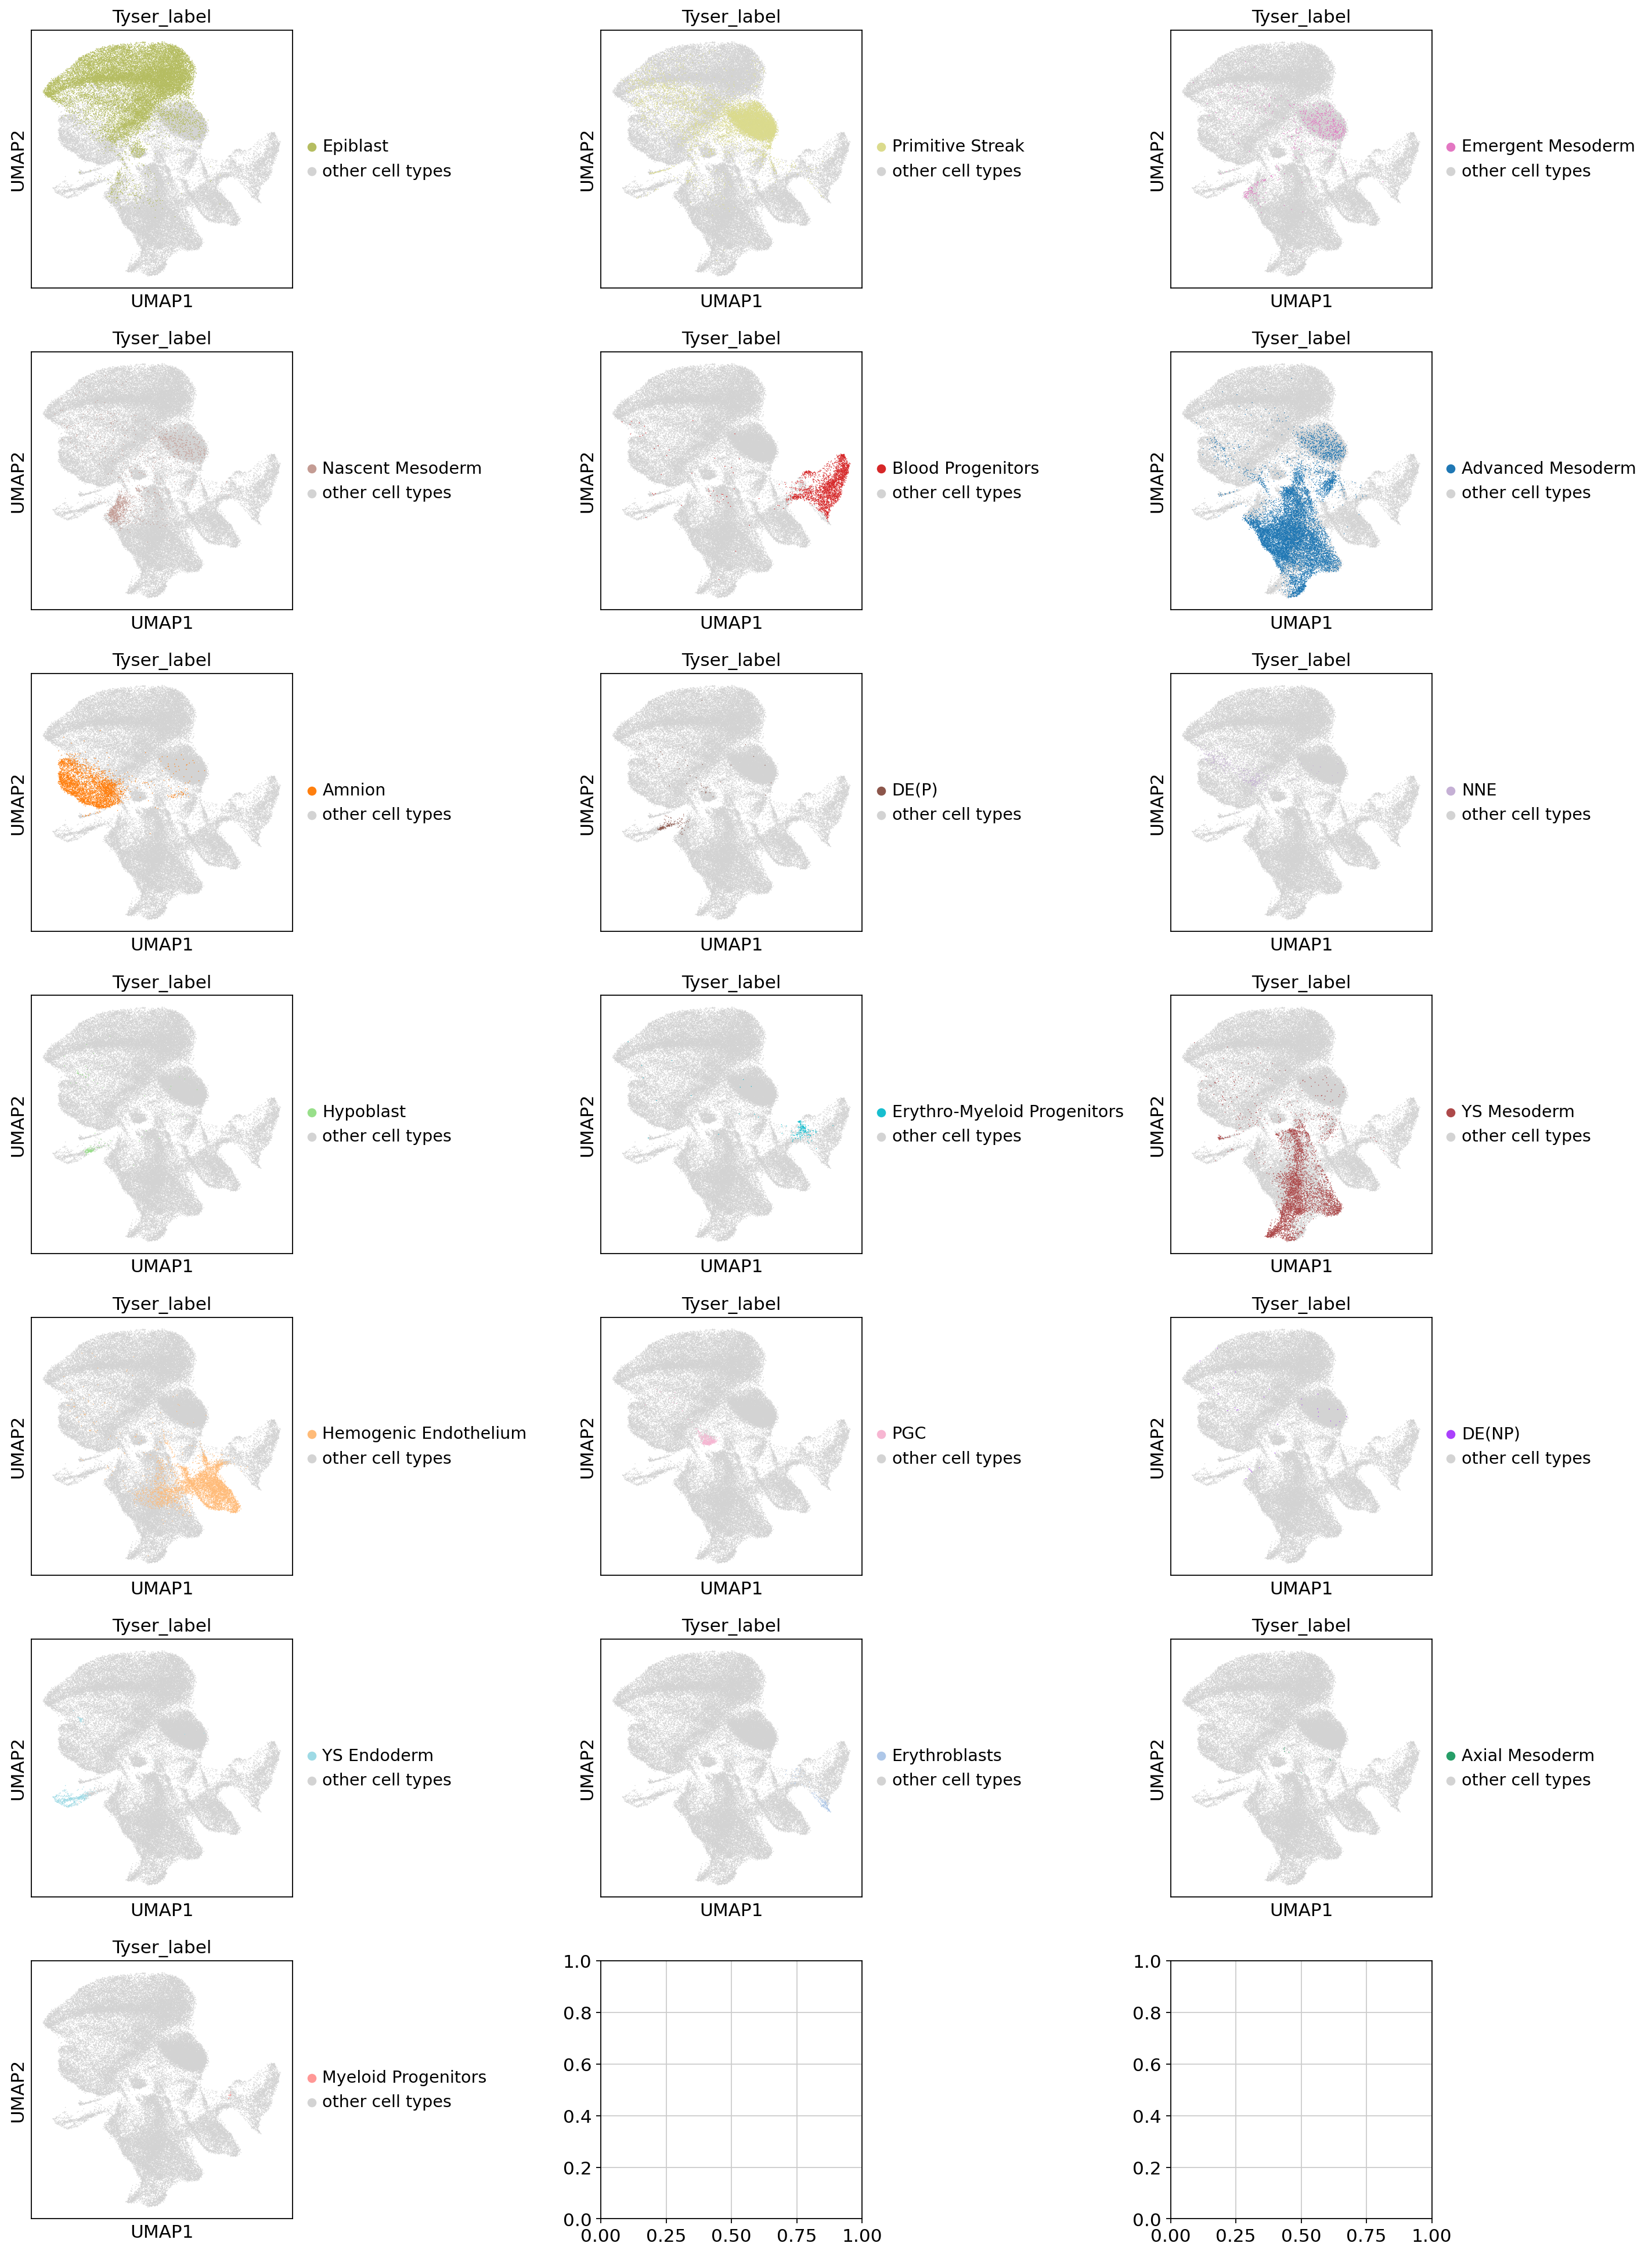

In [57]:
Tyser_label_present = adata.obs['Tyser_label'].unique()
num_plots = len(Tyser_label_present)
num_cols = 3
num_rows = -(-num_plots // num_cols) 

fig_width = num_cols * 6 
fig_height = num_rows * 3.5
fig, axs = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))

for i, label in enumerate(Tyser_label_present):
    row = i // num_cols
    col = i % num_cols
    ax = axs[row, col]

    sc.pl.umap(adata, color=["Tyser_label"], groups=[label], show=False, ax=ax)

    legend_texts = ax.get_legend().get_texts()
    for legend_text in legend_texts:
        if legend_text.get_text() == "NA":
            legend_text.set_text("other cell types")

    ax.set_aspect('auto', adjustable='box', anchor='C')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.1]})

# Counts
celltype_counts = pd.crosstab(adata.obs['sample'], adata.obs['CellType_man'])
celltype_counts.plot(kind='bar', stacked=True, ax=axes[0], legend=False, grid=False)
axes[0].set_title('Cell Type Counts by Sample')
axes[0].set_ylabel('Cell Count')
axes[0].tick_params(axis='x', rotation=45)

# Proportions
celltype_props = celltype_counts.div(celltype_counts.sum(axis=1), axis=0) * 100
celltype_props.plot(kind='bar', stacked=True, ax=axes[1], legend=False, grid=False)
axes[1].set_title('Cell Type Proportions by Sample')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=45)

# Legend
handles, labels = axes[0].get_legend_handles_labels()
axes[2].axis('off')
axes[2].legend(handles, labels, title='Cell Types', loc='center', frameon=False)

plt.tight_layout()
plt.savefig('/mnt/yiming/nfs_share/hema_wave/2512-revision/2_hemo10_barplot_cellprop.svg', 
            format='svg', dpi=300, bbox_inches='tight')
plt.show()
plt.close()